# Movie Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_theme(
    style='whitegrid',        
    palette='colorblind',     
    font='sans-serif',       
    rc={
        "axes.spines.top": False,    
        "axes.spines.right": False,  
        "axes.labelweight": "bold", 
        "axes.titleweight": "bold",  
        "axes.titlesize": 14,
        "figure.autolayout": True   
    }
)


In [3]:
movies = pd.read_csv('movies.csv')

In [4]:
# movies.describe()

In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        10 non-null     object
 1   Runtime      10 non-null     int64 
 2   Genre        10 non-null     object
 3   Wins         10 non-null     int64 
 4   Nominations  10 non-null     int64 
 5   BoxOffice    10 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 612.0+ bytes


In [6]:
movies.head()

,Title,Runtime,Genre,Wins,Nominations,BoxOffice
0,Parasite,132,"Drama, Thriller",309,261,53847897
1,Green Book,130,"Biography, Comedy, Drama",58,125,85080171
2,The Shape of Water,123,"Drama, Fantasy, Romance",138,350,63859435
3,Moonlight,111,Drama,235,310,27854932
4,Spotlight,129,"Biography, Crime, Drama",124,145,45055776


# What was the runtime for each movie?

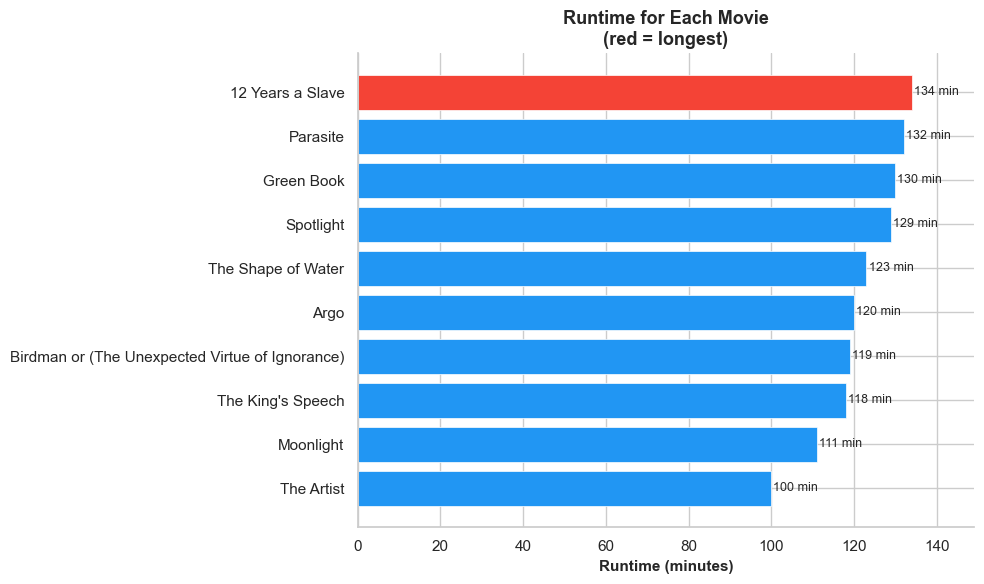

In [14]:
 df_sorted = movies.sort_values('Runtime', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3' if r != movies['Runtime'].max() else '#F44336' for r in df_sorted['Runtime']]
bars = ax.barh(df_sorted['Title'], df_sorted['Runtime'], color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, df_sorted['Runtime']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val} min', va='center', fontsize=9)

ax.set_xlabel('Runtime (minutes)', fontsize=11)
ax.set_title('Runtime for Each Movie\n(red = longest)', fontsize=13, fontweight='bold')
ax.set_xlim(0, df_sorted['Runtime'].max() + 15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# What movie had the longest runtime?
12 years a Slave had the longest runtime with a runtime about 140mins.
First, I sorted the movie dataset by runtime in ascending order to ensure a clean visual flow. I then generated a horizontal bar chart, mapping the movie titles to the vertical axis and their durations to the horizontal axis. i used a conditional statement to color the bar making the longest bar red.

# Is there any relationship between the length of the movie (runtime) and the number of awards a movie won?
There is no significant relationship between a movie's runtime and the number of awards it wins. As shown in the chart below, the correlation coefficient is 0.11, because this value is so close to zero, it indicates a negligible linear association between the two variables. I achieved this by using the regplot on the data and using correlation coefficient formular on 'Runtime' and 'Wins'.

Correlation coefficient: 0.11


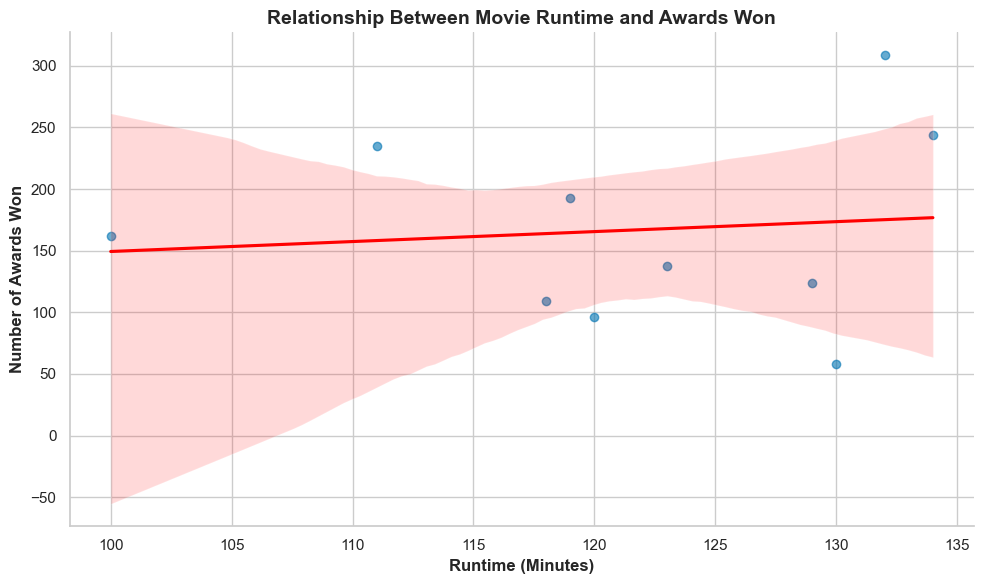

In [8]:
correlation = movies["Runtime"].corr(movies["Wins"])
print(f"Correlation coefficient: {correlation:.2f}")

plt.figure(figsize=(10, 6))

sns.regplot(data=movies, x="Runtime", y="Wins", scatter_kws={"alpha":0.6}, line_kws={"color":"red"})

plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Awards Won")
plt.title("Relationship Between Movie Runtime and Awards Won")

plt.tight_layout()
plt.show()

# How many awards and nominations did each movie receive?

The chart below shows each movie and their respective awards and nominations recieved.
**Parasite** being the movie with the most awards and **The Shape of Water** being the most nominated movie.
**Green Book** on the other hand is the movie with the least nominations and awards.
First, I applied the .melt() function to unpivot the dataset from a wide format into a long format. This consolidated the separate 'Wins' and 'Nominations' columns into a single 'Count' variable, categorized by a 'Metric' column.
i then plotted the data using seaborn barplot.


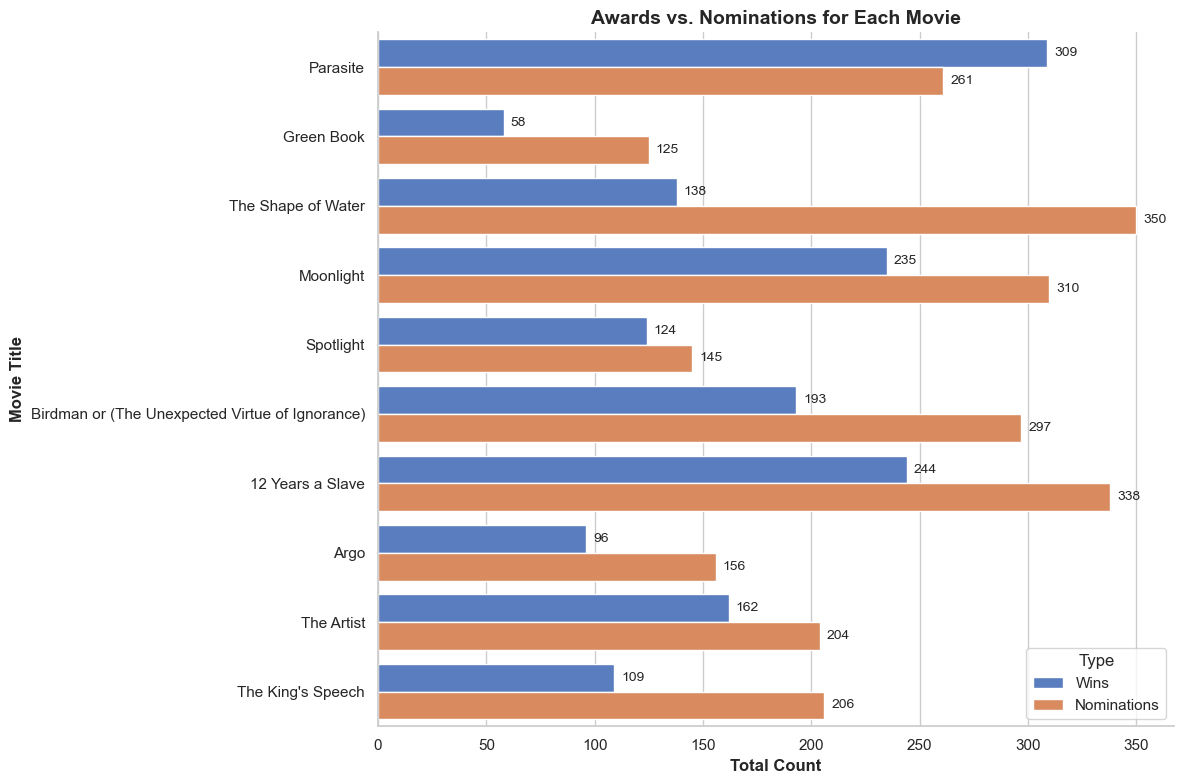

In [13]:
movies_data = movies.melt(
    id_vars="Title",
    value_vars=["Wins", "Nominations"],
    var_name="Metric",
    value_name="Count",
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=movies_data, x="Count", y="Title", hue="Metric", palette="muted")
for container in ax.containers:
    ax.bar_label(container, padding=5, fmt='%.0f', fontsize=10)
plt.xlabel("Total Count")
plt.ylabel("Movie Title")
plt.title("Awards vs. Nominations for Each Movie")
plt.legend(title="Type")


plt.tight_layout()
# fig.savefig('Awards & Nominations.png')
plt.show()


